<a href="https://colab.research.google.com/github/madhankumarm2408-sketch/Future_ML_02/blob/main/Support_Ticket_Classification_%26_Prioritization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk
import nltk
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('customer_support_tickets.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'customer_support_tickets.csv'

In [ ]:
# Check unique ticket descriptions
print("Total unique descriptions:", df['Ticket Description'].nunique())
print("Total rows:", len(df))

# Check how many contain unfilled placeholders
placeholder_count = df['Ticket Description'].str.contains(r'\{.*?\}', regex=True).sum()
print(f"\nDescriptions with unfilled placeholders: {placeholder_count}")

# Look at 5 random descriptions
print("\nSample descriptions:")
for desc in df['Ticket Description'].sample(5, random_state=1):
    print("-", desc[:150])

# Check category and priority distribution
print("\nTicket Type distribution:")
print(df['Ticket Type'].value_counts())

print("\nTicket Priority distribution:")
print(df['Ticket Priority'].value_counts())

# Check nulls in key columns
print("\nNulls in key columns:")
print(df[['Ticket Description', 'Ticket Type', 'Ticket Priority']].isnull().sum())

In [ ]:
def fix_placeholder(row):
  text = str(row['Ticket Description'])
  product = str(row['Product Purchased'])
  text = text.replace('{product_purchased}', product)
  return text

df['Description_Fixed'] = df.apply(fix_placeholder, axis=1)
df['Full_Text'] = df['Ticket Subject'] + ' ' + df['Description_Fixed']

print("BEFORE:")
print(df['Ticket Description'].iloc[0])
print("\nAFTER:")
print(df['Full_Text'].iloc[0])

In [ ]:
stop_words = set(stopwords.words('english'))
def clean_text(text):
  text = text.lower()
  text = re.sub(r'\S+@\S+', '', text)
  text = re.sub(r'[^a-z\s]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  words = text.split()
  words = [word for word in words if word not in stop_words and len(word) > 2]
  text = ' '.join(words)
  return text

df['Clean_Text'] = df['Full_Text'].apply(clean_text)
print("BEFORE CLEANING:")
print(df['Full_Text'].iloc[0])
print("\nAFTER CLEANING:")
print(df['Clean_Text'].iloc[0])

print("\n\n--- Another example ---")
print("BEFORE:")
print(df['Full_Text'].iloc[2])
print("\nAFTER:")
print(df['Clean_Text'].iloc[2])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['Clean_Text'])

print("Shape of TF-IDF matrix:", X.shape)
print("(rows= tickets, columns = important words)")

print("\nSample words/feature TF-IDF identified:")
print(tfidf.get_feature_names_out()[:30])

In [ ]:
y_category = df['Ticket Type']
y_priority = df['Ticket Priority']
print("Category classes:", y_category.unique())
print("Priority classes:", y_priority.unique())

In [ ]:
X_train, X_test,y_cat_train, y_cat_test = train_test_split(X, y_category, test_size=0.2, random_state=42, stratify=y_category)

print(f"Training tickets: {X_train.shape[0]}")
print(f"Testing tickets: {X_test.shape[0]}")


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

category_model = LogisticRegression(max_iter=1000)
category_model.fit(X_train, y_cat_train)

y_cat_pred = category_model.predict(X_test)

accuracy = accuracy_score(y_cat_test, y_cat_pred)
print(f"Category Classification Accuracy: {accuracy*100:.2f}%")
print("/nDetailed Report:")
print(classification_report(y_cat_test, y_cat_pred))

In [ ]:
print("Sample Sunjects by Category:")
for cat in df['Ticket Type'].unique():
  print(f"\n{cat}:")
  print(df[df['Ticket Type']==cat]['Ticket Subject'].unique()[:5])

## DATA QUALITY

During my initial EDA, I trained a Logistic Regression model on the Customer Support Ticket Database from Kaggale and observed accuracy of only 18.06% which is below the 20% baseline expected from the random guessing across the 5 different Categories.

Further Analysis revealed that the Ticket Subject value were not meaningful and correlated with the assigned Ticket type Category.

For example "Cancellation request" appeared as a subject under "Billing inquiry" category and "Payment issue" appeared across 3 different categories.

From the above analysis we could conclude that the given dataset is synthetically/randomly generated rather that derived from genuine text context. Making it unsuitable for supervised test classification.

In [ ]:
df2 = pd.read_csv('all_tickets_processed_improved_v3.csv')
print(df2.shape)
print(df2.columns.tolist())
print(df2.head())

(7877, 2)
['Document', 'Topic_group']
                                            Document    Topic_group
0  connection with icon icon dear please setup ic...       Hardware
1  work experience user work experience user hi w...         Access
2  requesting for meeting requesting meeting hi p...       Hardware
3  reset passwords for external accounts re expir...         Access
4  mail verification warning hi has got attached ...  Miscellaneous


In [ ]:
print("Topic_group distribution:")
print(df2['Topic_group'].value_counts())

print("\nNulls:")
print(df2.isnull().sum())

print("\nSample documents per category:")
for cat in df2['Topic_group'].unique():
    print(f"\n--- {cat} ---")
    sample = df2[df2['Topic_group']==cat]['Document'].iloc[0]
    print(sample[:200])

Topic_group distribution:
Topic_group
HR Support               1747
Hardware                 1657
Access                   1374
Miscellaneous            1251
Storage                   590
Purchase                  561
Internal Project          433
Administrative rights     263
Name: count, dtype: int64

Nulls:
Document       0
Topic_group    0
dtype: int64

Sample documents per category:

--- Hardware ---
connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead

--- Access ---
work experience user work experience user hi work experience student coming next his name much appreciate him duration thank

--- Miscellaneous ---
mail verification warning hi has got attached please addresses best regards monitoring analyst verification warning

--- HR Support ---
access request dear modules report report cost thank much regards

--- Purchase ---
system hello movement has left available device please kind device denmark copenhagen denmark p

In [ ]:
print(f"Before reomving nulls: {df2.shape}")
df2 = df2.dropna(subset=['Topic_group'])
print(f"After removing nulls: {df2.shape}")

print("/nTopic_group distribution:")
print(df2['Topic_group'].value_counts())

Before reomving nulls: (7877, 3)
After removing nulls: (7876, 3)
/nTopic_group distribution:
Topic_group
HR Support               1747
Hardware                 1657
Access                   1374
Miscellaneous            1251
Storage                   590
Purchase                  561
Internal Project          433
Administrative rights     263
Name: count, dtype: int64


In [ ]:
df2 = pd.read_csv("all_tickets_processed_improved_v3.csv")
print(f"Fresh load shape:{df2.shape}")

Fresh load shape:(7877, 2)


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
  if not isinstance(text, str):
    return ""

  text = text.lower()
  text = re.sub(r'[^a-zA-Z\s]', '',text)

  words = text.split()
  words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
  text = ' '.join(words)
  return text

df2['Clean_Text'] = df2['Document'].apply(clean_text)

print("Original:", df2['Document'].iloc[0][:100])
print("Cleaned:", df2['Clean_Text'].iloc[0][:100])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Original: connection with icon icon dear please setup icon per icon engineers please let other details needed 
Cleaned: connection icon icon dear please setup icon per icon engineer please let detail needed thanks lead


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df2['Clean_Text']
y = df2['Topic_group']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model_category = LogisticRegression(max_iter=1000, random_state=42)
model_category.fit(X_train_tfidf, y_train)

y_pred = model_category.predict(X_test_tfidf)

Accuracy: 0.8521573604060914

Classification Report (Presicion, recall, F1-Score):
                        precision    recall  f1-score   support

               Access       0.91      0.89      0.90       275
Administrative rights       0.88      0.68      0.77        53
           HR Support       0.86      0.86      0.86       350
             Hardware       0.74      0.90      0.81       331
     Internal Project       0.91      0.67      0.77        87
        Miscellaneous       0.83      0.84      0.84       250
             Purchase       1.00      0.91      0.95       112
              Storage       0.96      0.81      0.88       118

             accuracy                           0.85      1576
            macro avg       0.89      0.82      0.85      1576
         weighted avg       0.86      0.85      0.85      1576



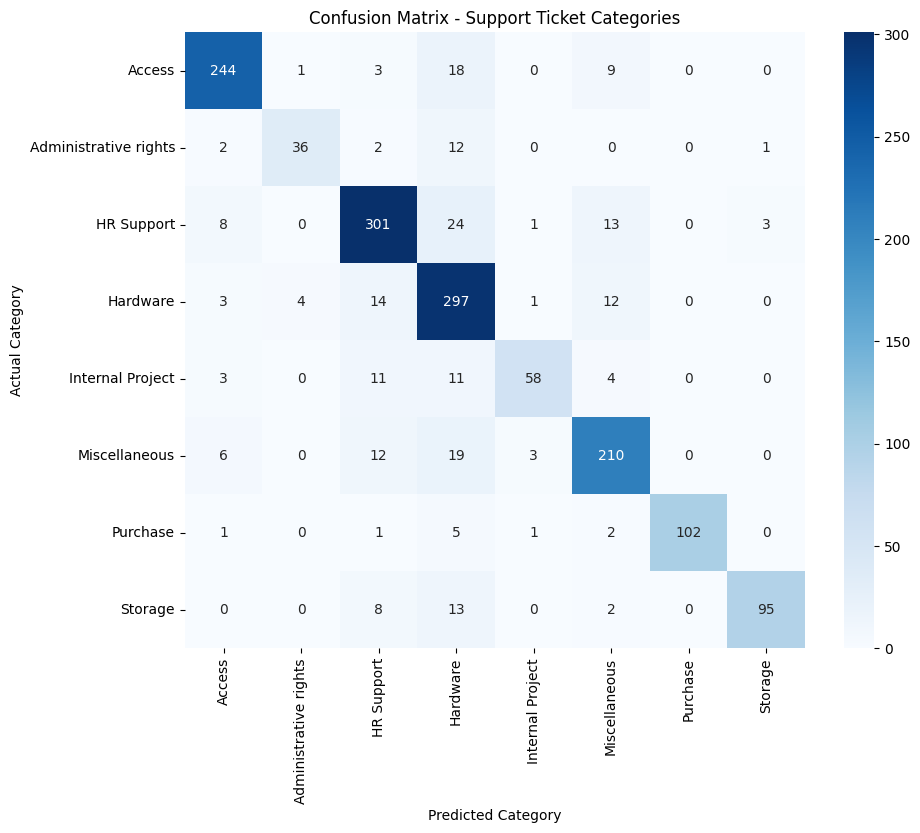

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report (Presicion, recall, F1-Score):\n", classification_report(y_test,y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_category.classes_, yticklabels=model_category.classes_)
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Confusion Matrix - Support Ticket Categories')
plt.show()

In [ ]:
priority_mapping = {
    'Access':'High',
    'Administrative rights': 'High',
    'Hardware': 'Medium',
    'Storage': 'Medium',
    'Purchase': 'Medium',
    'HR Support': 'Low',
    'Internal Project': 'Low',
    'Miscellaneous': 'Low'
}

def process_new_ticket(ticket_text):
  cleaned = clean_text(ticket_text)
  vectorized = tfidf.transform([cleaned])
  predicted_category = model_category.predict(vectorized)[0]

  assigned_priority = priority_mapping.get(predicted_category,'Medium')

  return {
      "Ticket Text": ticket_text,
      "Predicted Category": predicted_category,
      "Assigned Priority": assigned_priority
  }
test_ticket_1 = "I forgot my password and cannot log into the main company portal. Please help!"
test_ticket_2 = "We need to order 5 new wireless mice for the marketing team."

print("Test 1 Result:", process_new_ticket(test_ticket_1))
print("\nTest 2 Result:", process_new_ticket(test_ticket_2))


Test 1 Result: {'Ticket Text': 'I forgot my password and cannot log into the main company portal. Please help!', 'Predicted Category': 'Access', 'Assigned Priority': 'High'}

Test 2 Result: {'Ticket Text': 'We need to order 5 new wireless mice for the marketing team.', 'Predicted Category': 'Hardware', 'Assigned Priority': 'Medium'}
